# 06 · 실무 헤지 · 2022 영국 LDI · 2023 SVB — 레버리지 헤지는 현금 시험이다

[![Colab에서 열기](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/keerhee/pension-fund-strategy-and-performance/blob/main/W06_LDI%EC%99%80GBI/W06_M7_%EC%8B%A4%EC%8A%B5_Colab/06_%EC%8B%A4%EB%AC%B4%ED%97%A4%EC%A7%80_2022%EC%98%81%EA%B5%AD_SVB.ipynb)

**W06 M7 LDI 강의본 단원 ⑥ · ⑦ · ⑧(50~70장)** 의 숫자와 **실습데이터 덱**(`W06_M7_실습데이터_LDI부채연계투자.pdf` 단계 2~4)의 기대 결과를 재현합니다.

| 단계 | 강의 | 이 노트북에서 |
|---|---|---|
| 현물 · 스왑 · 증거금 | 51 · 53장 | Margin ≈ DV01_swap × Δy_bp · 안 C 사흘 +200bp 증거금 401조 vs 유동자산 123조 · TPR 버퍼 250bp |
| 2022 영국 | 56~61장 | £45B 감세(GDP 1.5%) · BOE £65B 발표 vs 실매입 £19.3B · 담보 현금 1~2% → 5~10% |
| 실습 B — 가상 부채 | 68장 · 실습 덱 12장 | PV 20,465억 · D 18.56 / 17.96년 · DV01 36.76억/bp · ±100bp −15.7% / +20.7% |
| 실습 C — 헤지 0 · 50 · 100% | 68장 · 실습 덱 13장 | 출발 FR 90% · ±100bp ΔFR −15.5/+16.8 · −6.9/+7.5 · +1.7/−1.9 |
| 실습 D — 레버리지 LDI 위기 | 69 · 70장 · 실습 덱 15 · 16장 | 버퍼 100bp → 3일차 고갈 · 강제매도 8.7% · 헤지 89% · FR −2.7%p / 250bp → 매도 0% · FR −0.9%p · 5배 · 7배 |
| 2023 SVB | 62 · 63 · 64장 | −6 × 117 × 0.025 ≈ −17.6(USD bn) ≈ 공시 평가손실 150억 달러+ |

가상 부채는 `W06_LDI와GBI/fml_w7_liability.csv`(**가상 데이터 — 강의용**, 실제 기관 자료 아님)의 연간 지급액을 노트북 안 상수로 옮겼습니다.
실습 덱 끝장이 가리키는 `lab_sim.py`는 저장소에 없어, 실습 덱 14장의 가정(현물 · 스왑 · 현금 버퍼 세 칸, 투매 할인 3%)으로 시뮬레이터를 다시 짰고 기대 결과가 그대로 나옵니다.

### 0. 준비 — 이 셀부터 실행
한글 폰트(Colab은 나눔고딕 설치, 맥은 Pretendard), 강의 색(잉크 · 라임 · 티일 · 빨강), 강의본 숫자 확인 함수 `check()`를 준비합니다.
`check(이름, 계산값, 강의값, 허용오차)`는 계산이 강의본 숫자와 허용오차 안에서 맞는지 확인하고, 틀리면 멈춥니다(`assert`).
가정을 바꿔 실험할 때는 `FAST = True`로 두면 확인이 멈추지 않고 ✗로 표시만 합니다(M7 세트는 계산이 가벼워 속도 차이는 없음).

In [1]:
# ── 환경 준비: 한글 폰트 · 강의 색 · 확인 함수 (이 셀을 먼저 실행) ──
import sys, os, glob, math, time, subprocess
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
from matplotlib import font_manager as fm

import warnings
warnings.filterwarnings("ignore", message=".*encountered in matmul")   # 맥 numpy(Accelerate)의 거짓 경고 — 결과와 무관
IN_COLAB = "google.colab" in sys.modules
if IN_COLAB and not glob.glob("/usr/share/fonts/truetype/nanum/NanumGothic*.ttf"):
    # Colab: 나눔 폰트 설치 (= !apt-get -qq install -y fonts-nanum) — 처음 한 번 10초 안팎
    subprocess.run("apt-get -qq install -y fonts-nanum > /dev/null", shell=True)

def setup_korean_font():
    """로컬 맥은 Pretendard, Colab은 나눔고딕을 matplotlib에 등록한다(폰트 캐시 갱신과 같은 효과)."""
    files = (glob.glob(os.path.expanduser("~/Library/Fonts/Pretendard-*.otf"))
             + glob.glob("/Library/Fonts/Pretendard-*.otf")
             + glob.glob("/usr/share/fonts/truetype/nanum/NanumGothic*.ttf"))
    for f in files:
        try:
            fm.fontManager.addfont(f)
        except Exception:
            pass
    names = {f.name for f in fm.fontManager.ttflist}
    for fam in ["Pretendard", "NanumGothic", "AppleGothic", "Malgun Gothic", "Noto Sans CJK KR"]:
        if fam in names:
            plt.rcParams["font.family"] = fam
            return fam
    return "(한글 폰트 없음 — 그래프 글자가 네모로 보이면 이 셀을 다시 실행)"

FONT = setup_korean_font()
plt.rcParams["axes.unicode_minus"] = False

# 강의 색 — 잉크 · 라임 · 티일 · 빨강 (+ 보조 회색 · 아이보리 바탕)
INK, LIME, TEAL, RED = "#071A1D", "#B7F34A", "#0B6B68", "#C00000"
GRAY, IVORY, OLIVE = "#8A9496", "#F7F5F0", "#5E8C1A"
plt.rcParams.update({
    "figure.figsize": (8, 4.5), "figure.dpi": 110, "savefig.dpi": 110,
    "figure.facecolor": "white", "axes.facecolor": IVORY,
    "axes.edgecolor": INK, "axes.labelcolor": INK, "xtick.color": INK, "ytick.color": INK,
    "axes.titleweight": "bold", "axes.titlesize": 13, "axes.titlelocation": "left",
    "axes.grid": True, "grid.color": "#DDD8CC", "grid.linewidth": 0.6,
    "axes.spines.top": False, "axes.spines.right": False,
    "legend.frameon": False, "axes.axisbelow": True,
    "axes.prop_cycle": matplotlib.cycler(color=[TEAL, INK, RED, OLIVE, GRAY]),
})

# 빠른 모드 — M7 세트는 계산이 가벼워 FAST가 결과를 바꾸지 않는다. True면 확인(check)이 멈추지 않고 표시만 한다(숫자를 바꿔 실험할 때)
FAST = False

CHECKS = []
def check(label, value, lecture, tol, fmt=".4f", unit=""):
    """계산값을 강의본 숫자와 비교한다. 기본(재현) 모드에서는 허용오차를 넘으면 멈춘다(assert)."""
    ok = abs(value - lecture) <= tol + 1e-9      # 허용오차는 보통 강의 표기 자릿수의 반(반올림하면 같은 값)
    CHECKS.append((label, ok))
    print(f"{'✓' if ok else '✗'} {label}: 계산 {value:{fmt}}{unit} · 강의 {lecture:{fmt}}{unit} (허용 ±{tol:g})")
    if not FAST:
        assert ok, f"{label}: 계산 {value} · 강의 {lecture}"

print(f"Colab: {IN_COLAB} · 그래프 폰트: {FONT} · numpy {np.__version__} · matplotlib {matplotlib.__version__}")

Colab: False · 그래프 폰트: Pretendard · numpy 2.0.2 · matplotlib 3.9.4


## 1. 변동증거금 — 스왑의 DV01 × 금리 변동 bp (강의 51 · 53장)
LBP(부채 벤치마크)는 성과의 기준, IRS 오버레이는 현금을 거의 쓰지 않고 듀레이션을 늘리는 지렛대입니다.
대가는 **변동증거금**: 금리가 오르면 고정금리 수취 스왑의 손실만큼 현금을 냅니다. **Margin ≈ DV01_swap × Δy_bp**.

국민연금 안 C(07 노트북): 30년 고정금리 수취 스왑 명목 1,223조, 30년 IRS 고정금리 4.45%(국고채 4.60% − 스프레드 0.15%p)의 수정 듀레이션 16.4년.

In [2]:
def par_mod_duration(T, y_pct):
    """만기 T년, 연 이표 = 수익률인 액면가 채권(= 스왑 고정 다리)의 수정 듀레이션"""
    c = y_pct / 100; t = np.arange(1, T + 1)
    pv = c / (1 + c) ** t; pv[-1] += 1 / (1 + c) ** T
    return float(np.sum(t * pv) / (1 + c))

D_irs = par_mod_duration(30, 4.60 - 0.15)
notional_C = 1223.0
dv01_swap = notional_C * D_irs * 1e-4           # 조원/bp
margin_3d = dv01_swap * 200                      # 사흘 +200bp
buffer_250 = dv01_swap * 250
LIQUID = 4.6 + 118.6                             # 단기자금 + 국고채 보유(조) — 케이스 데이터 fml_w6m7_assets.csv
print(f"IRS 30년 수정 듀레이션 {D_irs:.1f}년 · 스왑 DV01 = 1,223 × {D_irs:.1f} × 0.0001 = {dv01_swap:.2f}조/bp")
print(f"사흘 +200bp 증거금 ≈ {margin_3d:.0f}조 · TPR 250bp 버퍼 {buffer_250:.0f}조 vs 담보 적격 유동자산 {LIQUID:.1f}조 (×{margin_3d / LIQUID:.1f})")
check("IRS 30년 수정 듀레이션 (년)", D_irs, 16.4, 0.05, ".2f")
check("안 C 사흘 +200bp 증거금 (조)", margin_3d, 401, 0.5, ".1f")
check("NPS 유동자산 (조)", LIQUID, 123, 0.5, ".1f")

IRS 30년 수정 듀레이션 16.4년 · 스왑 DV01 = 1,223 × 16.4 × 0.0001 = 2.00조/bp
사흘 +200bp 증거금 ≈ 401조 · TPR 250bp 버퍼 501조 vs 담보 적격 유동자산 123.2조 (×3.3)
✓ IRS 30년 수정 듀레이션 (년): 계산 16.39 · 강의 16.40 (허용 ±0.05)
✓ 안 C 사흘 +200bp 증거금 (조): 계산 400.8 · 강의 401.0 (허용 ±0.5)
✓ NPS 유동자산 (조): 계산 123.2 · 강의 123.0 (허용 ±0.5)


## 2. 2022 영국 LDI — 숫자로 읽는 32일 (강의 56~61장)
| 날짜 | 사건 |
|---|---|
| 9/23 | 미니예산 — £45B 감세(GDP 1.5%), 파운드 −3.6% |
| 9/26 | 파운드 역대 최저(1.03) · LDI 증거금 경보 |
| 9/27 | 30년 Gilt 나흘 새 +1%p 이상 · Gilt 대량 매각 |
| 9/28 | BOE £65B 매입 발표 — 13일 한정 (실매입 £19.3B) |
| 10/25 | Truss 사임 — 재임 49일 |

손실 추정 £150B, 2021년 레버리지 LDI 약 £1.5조, 담보 현금 1~2% 보유 → 위기 시 5~10% 필요(61장 교훈 ③).

In [3]:
gdp = 45 / 0.015
print(f"£45B = GDP의 1.5% → 영국 GDP ≈ £{gdp / 1000:.1f}조")
print(f"BOE: 발표 £65B 중 실매입 £19.3B = {19.3 / 65:.0%} — '무제한 의지'의 신호가 핵심")
print(f"LDI £1.5조에 담보 현금 1~2% = £{1500 * 0.01:.0f}~{1500 * 0.02:.0f}B · 위기 때 5~10% = £{1500 * 0.05:.0f}~{1500 * 0.10:.0f}B 필요")
# 30년 Gilt 나흘 +1%p: 레버리지 3배 LDI(헤지 100%, 부채 D 20 가정)의 담보 수요 — 자산 대비
for lev in [3, 5, 7]:
    q = 1 - 1 / lev
    print(f"  레버리지 {lev}배: 스왑 몫 {q:.0%} × D 20 × 1%p = 부채 대비 {q * 20 * 0.01:.0%}의 현금")
check("BOE 실매입 비율 (%)", 100 * 19.3 / 65, 30, 0.5, ".1f")

£45B = GDP의 1.5% → 영국 GDP ≈ £3.0조
BOE: 발표 £65B 중 실매입 £19.3B = 30% — '무제한 의지'의 신호가 핵심
LDI £1.5조에 담보 현금 1~2% = £15~30B · 위기 때 5~10% = £75~150B 필요
  레버리지 3배: 스왑 몫 67% × D 20 × 1%p = 부채 대비 13%의 현금
  레버리지 5배: 스왑 몫 80% × D 20 × 1%p = 부채 대비 16%의 현금
  레버리지 7배: 스왑 몫 86% × D 20 × 1%p = 부채 대비 17%의 현금
✓ BOE 실매입 비율 (%): 계산 29.7 · 강의 30.0 (허용 ±0.5)


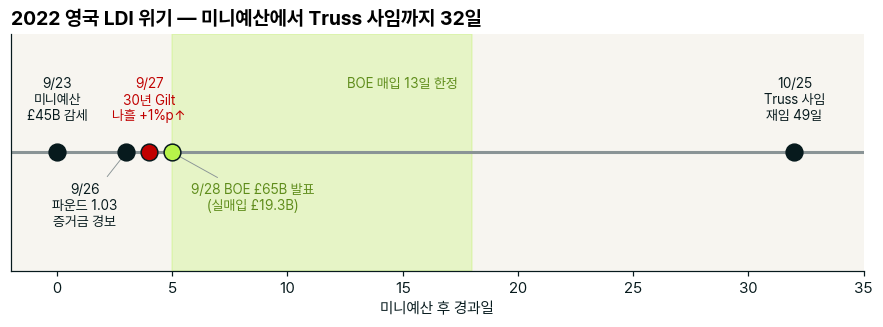

In [4]:
fig, ax = plt.subplots(figsize=(10, 2.8))
ev = [(0, 0, 0.25, "9/23\n미니예산\n£45B 감세", INK), (3, 1.2, -0.25, "9/26\n파운드 1.03\n증거금 경보", INK),
      (4, 4, 0.25, "9/27\n30년 Gilt\n나흘 +1%p↑", RED), (5, 8.5, -0.25, "9/28 BOE £65B 발표\n(실매입 £19.3B)", OLIVE),
      (32, 32, 0.25, "10/25\nTruss 사임\n재임 49일", INK)]
ax.axhline(0, color=GRAY, lw=2)
for x, lx, ly, lab, c in ev:
    ax.scatter(x, 0, s=120, color=LIME if c == OLIVE else c, edgecolor=INK, zorder=5)
    ax.annotate(lab, (x, 0), xytext=(lx, ly), ha="center", va="bottom" if ly > 0 else "top", fontsize=9, color=c,
                arrowprops=dict(arrowstyle="-", color=GRAY, lw=0.6) if lx != x else None)
ax.axvspan(5, 18, color=LIME, alpha=0.25); ax.text(15, 0.55, "BOE 매입 13일 한정", ha="center", color=OLIVE, fontsize=9)
ax.set_ylim(-1, 1); ax.set_yticks([]); ax.set_xlim(-2, 35); ax.set_xlabel("미니예산 후 경과일"); ax.grid(False)
ax.set_title("2022 영국 LDI 위기 — 미니예산에서 Truss 사임까지 32일")
plt.show()

## 3. 실습 B — 가상 DB 부채의 PV · 듀레이션 · DV01 (강의 68장 · 실습 덱 5 · 12장)
가상 DB 연금(가입자 10,000명), 2026~2076년 51개 연도 **연초 지급**(t = 0부터 할인), 물가연동 2%가 반영된 명목액(억원). 단일 할인율 3.3%.

In [5]:
# 가상 데이터 — 강의용 (실제 기관 · 개인의 자료가 아니다) · 출처: W06_LDI와GBI/fml_w7_liability.csv '연간지급액_억원'
PAY = np.array([
    791.25, 792.98, 772.85, 751.38, 733.65, 720.93, 710.58, 704.02, 700.48, 697.3,
    694.27, 698.6, 708.8, 720.9, 737.99, 759.35, 774.34, 798.59, 824.64, 856.24,
    887.8, 920.04, 965.87, 994.89, 1024.85, 1056.86, 1080.39, 1097.46, 1115.57, 1129.28,
    1132.49, 1130.29, 1111.14, 1085.14, 1055.25, 1017.36, 980.36, 933.06, 879.68, 824.13,
    794.63, 730.31, 667.43, 606.04, 546.7, 489.63, 435.35, 384.07, 335.84, 291.48,
    250.72,
])
t = np.arange(len(PAY)); YEARS = 2026 + t

def L_pv(y, start=0):
    """연초 지급 — t = start부터 할인(start=1은 흔한 오류)"""
    return float(np.sum(PAY / (1 + y) ** (t + start)))

y0 = 0.033
L0 = L_pv(y0)
mac = float(np.sum(t * PAY / (1 + y0) ** t)) / L0
mod = mac / (1 + y0)
DV01_L = mod * L0 * 1e-4
up, dn = L_pv(y0 + 0.01) / L0 - 1, L_pv(y0 - 0.01) / L0 - 1
print("가상 데이터 — 강의용")
print(f"부채 PV {L0:,.0f}억 · Macaulay D {mac:.2f}년 · 수정 D {mod:.2f}년 · DV01 {DV01_L:.2f}억/bp")
print(f"금리 +100bp: PV {up:+.1%} · −100bp: PV {dn:+.1%} — 볼록성 때문에 하락 쪽 충격이 더 크다")
print(f"할인율 3.5%면 {L_pv(0.035):,.0f}억 · 정점 지급 {YEARS[PAY.argmax()]}년 {PAY.max():,.0f}억 · (오류) t = 1부터 할인하면 {L_pv(y0, 1):,.0f}억")
check("부채 PV (억)", L0, 20465, 0.5, ",.0f")
check("Macaulay 듀레이션 (년)", mac, 18.56, 0.005, ".3f")
check("수정 듀레이션 (년)", mod, 17.96, 0.005, ".3f")
check("DV01 (억/bp)", DV01_L, 36.76, 0.005, ".3f")
check("+100bp PV 변화 (%)", 100 * up, -15.7, 0.05, ".2f")
check("−100bp PV 변화 (%)", 100 * dn, 20.7, 0.05, ".2f")
check("할인율 3.5% PV (억)", L_pv(0.035), 19749, 0.5, ",.0f")
check("정점 지급 (억)", PAY.max(), 1132, 0.5, ",.0f")
check("t = 1부터 할인한 PV (억, 오류 예)", L_pv(y0, 1), 19811, 0.5, ",.0f")

가상 데이터 — 강의용
부채 PV 20,465억 · Macaulay D 18.56년 · 수정 D 17.96년 · DV01 36.76억/bp
금리 +100bp: PV -15.7% · −100bp: PV +20.7% — 볼록성 때문에 하락 쪽 충격이 더 크다
할인율 3.5%면 19,749억 · 정점 지급 2056년 1,132억 · (오류) t = 1부터 할인하면 19,811억
✓ 부채 PV (억): 계산 20,465 · 강의 20,465 (허용 ±0.5)
✓ Macaulay 듀레이션 (년): 계산 18.556 · 강의 18.560 (허용 ±0.005)
✓ 수정 듀레이션 (년): 계산 17.963 · 강의 17.960 (허용 ±0.005)
✓ DV01 (억/bp): 계산 36.762 · 강의 36.760 (허용 ±0.005)
✓ +100bp PV 변화 (%): 계산 -15.73 · 강의 -15.70 (허용 ±0.05)
✓ −100bp PV 변화 (%): 계산 20.74 · 강의 20.70 (허용 ±0.05)
✓ 할인율 3.5% PV (억): 계산 19,749 · 강의 19,749 (허용 ±0.5)
✓ 정점 지급 (억): 계산 1,132 · 강의 1,132 (허용 ±0.5)
✓ t = 1부터 할인한 PV (억, 오류 예): 계산 19,811 · 강의 19,811 (허용 ±0.5)


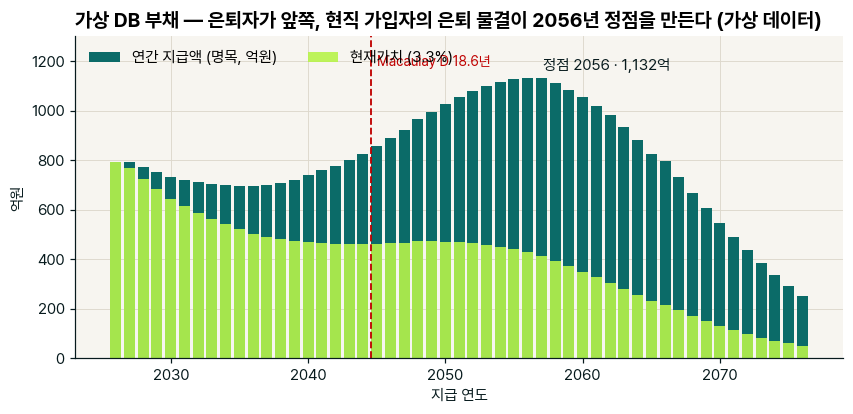

In [6]:
fig, ax = plt.subplots(figsize=(9, 3.8))
ax.bar(YEARS, PAY, color=TEAL, edgecolor="none", label="연간 지급액 (명목, 억원)")
ax.bar(YEARS, PAY / (1 + y0) ** t, color=LIME, edgecolor="none", alpha=0.9, label="현재가치 (3.3%)")
ax.annotate(f"정점 {YEARS[PAY.argmax()]} · {PAY.max():,.0f}억", (YEARS[PAY.argmax()], PAY.max()), textcoords="offset points", xytext=(10, 5), color=INK)
ax.axvline(2026 + mac, color=RED, ls="--", lw=1.2); ax.text(2026 + mac + 0.5, 1180, f"Macaulay D {mac:.1f}년", color=RED, fontsize=9)
ax.set_ylim(0, 1300); ax.set_xlabel("지급 연도"); ax.set_ylabel("억원")
ax.set_title("가상 DB 부채 — 은퇴자가 앞쪽, 현직 가입자의 은퇴 물결이 2056년 정점을 만든다 (가상 데이터)")
ax.legend(loc="upper left", ncol=2)
plt.show()

## 4. 실습 C — 헤지비율 0 · 50 · 100%의 적립비율 (강의 68장 · 실습 덱 13장)
출발 FR 90%(자산 = 0.9 × 부채 PV). 헤지 자산이 부채를 복제한다고 보면 금리 변화 시 자산은 h × (L₁ − L₀)만큼 움직입니다.
FR₁ = (A₀ + h·(L₁ − L₀)) ÷ L₁, 금리 ±100bp 평행 이동(부채는 다시 할인 — 볼록성 포함).

In [7]:
A0 = 0.9 * L0
LECT_C = {0.0: (-15.5, 16.8), 0.5: (-6.9, 7.5), 1.0: (1.7, -1.9)}
print(f"{'헤지':>6s} {'−100bp ΔFR':>12s} {'+100bp ΔFR':>12s}")
for h, (l_dn, l_up) in LECT_C.items():
    out = []
    for s in (-0.01, 0.01):
        L1 = L_pv(y0 + s)
        out.append(100 * ((A0 + h * (L1 - L0)) / L1 - 0.9))
    print(f"{h:6.0%} {out[0]:+11.1f}%p {out[1]:+11.1f}%p")
    check(f"헤지 {h:.0%} · −100bp ΔFR (%p)", out[0], l_dn, 0.05, "+.2f")
    check(f"헤지 {h:.0%} · +100bp ΔFR (%p)", out[1], l_up, 0.05, "+.2f")

    헤지   −100bp ΔFR   +100bp ΔFR
    0%       -15.5%p       +16.8%p
✓ 헤지 0% · −100bp ΔFR (%p): 계산 -15.46 · 강의 -15.50 (허용 ±0.05)
✓ 헤지 0% · +100bp ΔFR (%p): 계산 +16.81 · 강의 +16.80 (허용 ±0.05)
   50%        -6.9%p        +7.5%p
✓ 헤지 50% · −100bp ΔFR (%p): 계산 -6.87 · 강의 -6.90 (허용 ±0.05)
✓ 헤지 50% · +100bp ΔFR (%p): 계산 +7.47 · 강의 +7.50 (허용 ±0.05)
  100%        +1.7%p        -1.9%p
✓ 헤지 100% · −100bp ΔFR (%p): 계산 +1.72 · 강의 +1.70 (허용 ±0.05)
✓ 헤지 100% · +100bp ΔFR (%p): 계산 -1.87 · 강의 -1.90 (허용 ±0.05)


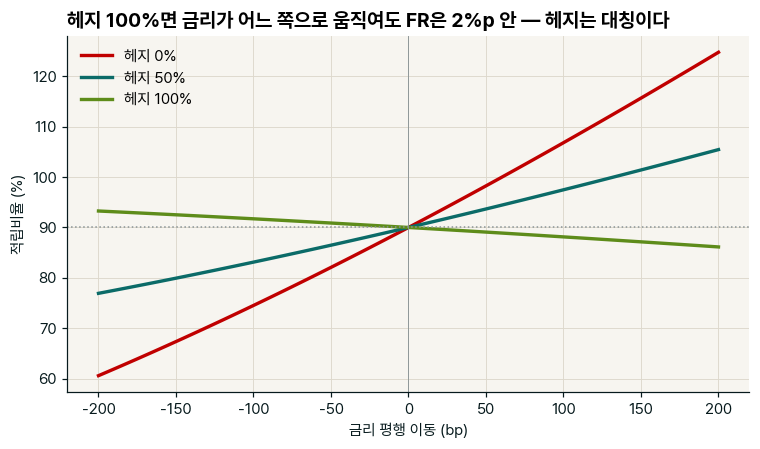

In [8]:
shifts = np.linspace(-200, 200, 81)
fig, ax = plt.subplots(figsize=(8, 4.2))
for h, c in [(0.0, RED), (0.5, TEAL), (1.0, OLIVE)]:
    fr = [100 * (A0 + h * (L_pv(y0 + s / 1e4) - L0)) / L_pv(y0 + s / 1e4) for s in shifts]
    ax.plot(shifts, fr, color=c, lw=2.2, label=f"헤지 {h:.0%}")
ax.axhline(90, color=GRAY, ls=":", lw=1); ax.axvline(0, color=GRAY, lw=0.6)
ax.set_xlabel("금리 평행 이동 (bp)"); ax.set_ylabel("적립비율 (%)")
ax.set_title("헤지 100%면 금리가 어느 쪽으로 움직여도 FR은 2%p 안 — 헤지는 대칭이다")
ax.legend()
plt.show()

## 5. 실습 D — 레버리지 LDI 위기 시뮬레이터 (강의 69 · 70장 · 실습 덱 14~17장)
**가정(실습 덱 10 · 14장)** — 단일 기금 모형, 시장 가격 충격(Doom Loop)은 넣지 않는다.
- 출발 FR 90% · 헤지 100% = 현물 p + 스왑 q, 레버리지 3배면 p = 1/3 · q = 2/3 (부채 대비 비중)
- 현금 버퍼 = 스왑 DV01 × 버퍼(bp), 나머지 자산은 성장자산(금리 무관)
- 금리 +50bp × 3일 → 매일 변동증거금 납부(부채를 다시 할인한 정확한 손익 — 볼록성 때문에 하루 증거금은 50bp × DV01보다 조금 작다)
- 버퍼가 바닥나면 현물을 **3% 할인**으로 팔아 메우고, 레버리지 3배를 지키려 스왑을 현물의 2배로 줄인다
- 4일차 −100bp 되돌림(중앙은행 개입)
- 강제 매도 비율 = 판 현물(장부가) ÷ 출발 현물, 남은 헤지 = 현물 + 스왑(부채 대비)

In [9]:
def ldi_crisis(buffer_bp, path_bp=(50, 50, 50, -100), lev=3, FR0=0.9, haircut=0.03):
    p0 = 1 / lev; q0 = 1 - p0
    p, q = p0, q0
    cash = q0 * DV01_L * buffer_bp                     # 현금 버퍼(억)
    growth = FR0 * L0 - p0 * L0 - cash                 # 금리와 무관한 성장자산
    y, L_prev = y0, L0
    sold, short_day, cash_path = 0.0, None, [cash]
    for day, dy in enumerate(path_bp, 1):
        y += dy / 1e4; L_new = L_pv(y)
        cash += q * (L_new - L_prev)                   # 수취 스왑 손익 = 변동증거금(+면 받음)
        if cash < 0:                                   # 버퍼 고갈 → 현물 투매
            need = -cash; sell = need / (1 - haircut)
            p -= sell / L_new; q = (lev - 1) * p
            sold += sell; cash = 0.0
            short_day = short_day or day
        cash_path.append(cash); L_prev = L_new
    A_end = growth + p * L_prev + cash
    return {"부족일": short_day, "강제매도": sold / (p0 * L0), "남은헤지": p + q, "최종FR": A_end / L_prev,
            "ΔFR": A_end / L_prev - FR0, "버퍼경로": cash_path}

SCEN = [("버퍼 100bp · 균등 +50×3", dict(buffer_bp=100), (3, 8.7, 89, 87.3, -2.7)),
        ("버퍼 150bp · 균등", dict(buffer_bp=150), (None, 0, 100, 89.1, -0.9)),
        ("버퍼 250bp · 균등", dict(buffer_bp=250), (None, 0, 100, 89.1, -0.9)),
        ("버퍼 100bp · 전방 +100, +50", dict(buffer_bp=100, path_bp=(100, 50, -100)), (2, 8.7, 89, 87.3, -2.7)),
        ("버퍼 100bp · 레버리지 5배", dict(buffer_bp=100, lev=5), (3, 17.4, 78, 85.6, -4.4)),
        ("버퍼 100bp · 레버리지 7배", dict(buffer_bp=100, lev=7), (3, 26.1, 67, 83.9, -6.1))]
RES = {}
print("가상 데이터 — 강의용 · 단일 기금 · 가격 충격 미포함 모형")
print(f"{'시나리오':28s} {'버퍼 부족':>8s} {'강제 매도':>9s} {'남은 헤지':>9s} {'최종 FR':>8s} {'ΔFR':>7s}")
for name, kw, lec in SCEN:
    r = ldi_crisis(**kw); RES[name] = r
    sd = f"{r['부족일']}일차" if r["부족일"] else "없음"
    print(f"{name:28s} {sd:>8s} {r['강제매도']:9.1%} {r['남은헤지']:9.0%} {r['최종FR']:8.1%} {100 * r['ΔFR']:+6.1f}%p")
    check(f"{name} 부족일", r["부족일"] or 0, lec[0] or 0, 0, ".0f")
    check(f"{name} 강제 매도 (%)", 100 * r["강제매도"], lec[1], 0.05, ".2f")
    check(f"{name} 남은 헤지 (%)", 100 * r["남은헤지"], lec[2], 0.5, ".1f")
    check(f"{name} 최종 FR (%)", 100 * r["최종FR"], lec[3], 0.05, ".2f")
    check(f"{name} ΔFR (%p)", 100 * r["ΔFR"], lec[4], 0.05, ".2f")
left250 = RES["버퍼 250bp · 균등"]["버퍼경로"][3]
print(f"250bp 버퍼는 3일차에 {left250:,.0f}억 남음 · 하루 증거금(1일차) {-(RES['버퍼 250bp · 균등']['버퍼경로'][1] - RES['버퍼 250bp · 균등']['버퍼경로'][0]):,.0f}억 < 50bp × 스왑 DV01 {50 * DV01_L * 2 / 3:,.0f}억")
check("250bp 버퍼 3일차 잔액 (억)", left250, 3102, 0.5, ",.0f")

가상 데이터 — 강의용 · 단일 기금 · 가격 충격 미포함 모형
시나리오                            버퍼 부족     강제 매도     남은 헤지    최종 FR     ΔFR
버퍼 100bp · 균등 +50×3               3일차      8.7%       89%    87.3%   -2.7%p
✓ 버퍼 100bp · 균등 +50×3 부족일: 계산 3 · 강의 3 (허용 ±0)
✓ 버퍼 100bp · 균등 +50×3 강제 매도 (%): 계산 8.68 · 강의 8.70 (허용 ±0.05)
✓ 버퍼 100bp · 균등 +50×3 남은 헤지 (%): 계산 88.8 · 강의 89.0 (허용 ±0.5)
✓ 버퍼 100bp · 균등 +50×3 최종 FR (%): 계산 87.31 · 강의 87.30 (허용 ±0.05)
✓ 버퍼 100bp · 균등 +50×3 ΔFR (%p): 계산 -2.69 · 강의 -2.70 (허용 ±0.05)
버퍼 150bp · 균등                      없음      0.0%      100%    89.1%   -0.9%p
✓ 버퍼 150bp · 균등 부족일: 계산 0 · 강의 0 (허용 ±0)
✓ 버퍼 150bp · 균등 강제 매도 (%): 계산 0.00 · 강의 0.00 (허용 ±0.05)
✓ 버퍼 150bp · 균등 남은 헤지 (%): 계산 100.0 · 강의 100.0 (허용 ±0.5)
✓ 버퍼 150bp · 균등 최종 FR (%): 계산 89.08 · 강의 89.10 (허용 ±0.05)
✓ 버퍼 150bp · 균등 ΔFR (%p): 계산 -0.92 · 강의 -0.90 (허용 ±0.05)
버퍼 250bp · 균등                      없음      0.0%      100%    89.1%   -0.9%p
✓ 버퍼 250bp · 균등 부족일: 계산 0 · 강의 0 (허용 ±0)
✓ 버퍼 250bp · 균등 강제 매도 (%): 계산 0.00 · 강의 0.00 (허용 ±0.05

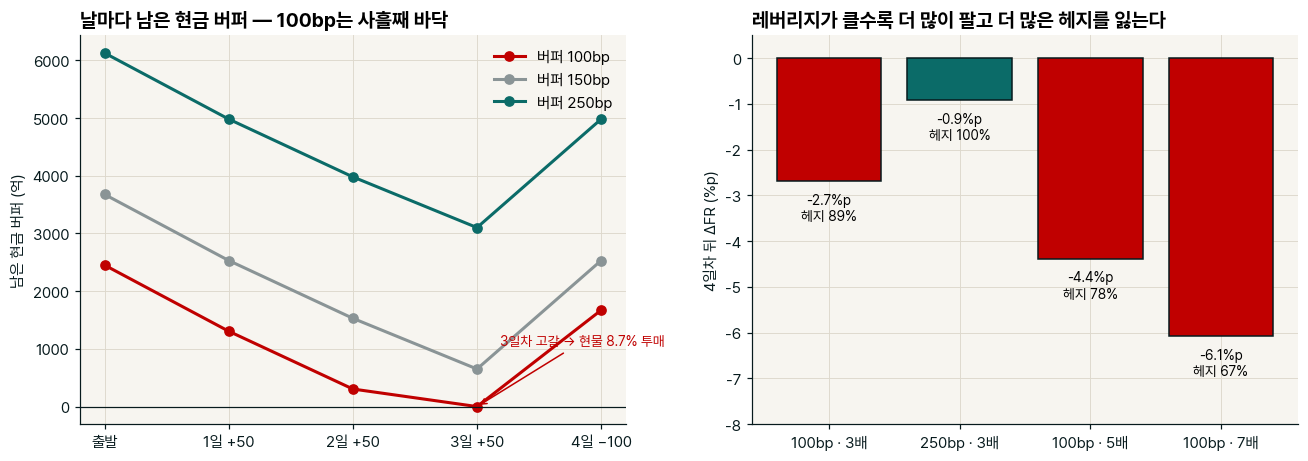

In [10]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4.3))
for name, c in [("버퍼 100bp · 균등 +50×3", RED), ("버퍼 150bp · 균등", GRAY), ("버퍼 250bp · 균등", TEAL)]:
    ax1.plot(range(5), RES[name]["버퍼경로"], marker="o", color=c, lw=2, label=name.split(" · ")[0])
ax1.axhline(0, color=INK, lw=0.8)
ax1.annotate("3일차 고갈 → 현물 8.7% 투매", (3, 0), textcoords="offset points", xytext=(15, 40), color=RED, fontsize=9, arrowprops=dict(arrowstyle="->", color=RED))
ax1.set_xticks(range(5), ["출발", "1일 +50", "2일 +50", "3일 +50", "4일 −100"])
ax1.set_ylabel("남은 현금 버퍼 (억)"); ax1.set_title("날마다 남은 현금 버퍼 — 100bp는 사흘째 바닥"); ax1.legend()
names = ["버퍼 100bp · 균등 +50×3", "버퍼 250bp · 균등", "버퍼 100bp · 레버리지 5배", "버퍼 100bp · 레버리지 7배"]
labs = ["100bp · 3배", "250bp · 3배", "100bp · 5배", "100bp · 7배"]
vals = [100 * RES[n]["ΔFR"] for n in names]
bars = ax2.bar(labs, vals, color=[RED, TEAL, RED, RED], edgecolor=INK)
for b, n, v in zip(bars, names, vals):
    ax2.text(b.get_x() + b.get_width() / 2, v - 0.25, f"{v:+.1f}%p\n헤지 {RES[n]['남은헤지']:.0%}", ha="center", va="top", fontsize=9)
ax2.set_ylim(-8, 0.5); ax2.set_ylabel("4일차 뒤 ΔFR (%p)")
ax2.set_title("레버리지가 클수록 더 많이 팔고 더 많은 헤지를 잃는다")
fig.tight_layout(); plt.show()

**재현되지 않는 것 — "일부 기금 FR −30%p"(강의 58 · 69장, 실습 덱 17장).** 이 모형은 한 기금의 산수라 7배여도 −6.1%p입니다.
붕괴의 크기는 1,000개 기금의 동시 매도가 Gilt 가격을 떨어뜨려 금리를 다시 올리는 **시장 전체의 가격 충격(Doom Loop)** 에서 나옵니다.
발언할 때는 "단일 기금 · 가격 충격 미포함 모형 기준"이라고 가정을 함께 말합니다.

## 6. 2023 SVB — 반대 방향의 갭, 같은 현금 시험 (강의 62 · 63 · 64장)
2022년 말 SVB: 총자산 2,090억 · 예금 1,755억(비보호 약 86%) · 채권 1,170억 달러. **듀레이션 6년 · 금리 +2.5%p는 손계산용 가정치.**

In [11]:
D_svb, V_svb, dy_svb = 6, 117, 0.025
loss = -D_svb * V_svb * dy_svb
print(f"ΔV ≈ −D·V·Δy = −6 × 117 × 0.025 = {loss:.1f} (USD bn, 약 {-loss * 10:.0f}억 달러) ≈ 공시 평가손실 150억 달러+ (자기자본과 비슷한 규모)")
print(f"비보호 예금 ≈ 1,755억 × 86% = {1755 * 0.86:,.0f}억 달러 · 3/9 하루 인출 420억 = 예금의 {420 / 1755:.0%}")
check("SVB 평가손실 손계산 (USD bn)", loss, -17.6, 0.05, ".2f")
check("손계산 ≥ 공시 150억 달러", float(-loss >= 15), 1, 0, ".0f")

ΔV ≈ −D·V·Δy = −6 × 117 × 0.025 = -17.6 (USD bn, 약 176억 달러) ≈ 공시 평가손실 150억 달러+ (자기자본과 비슷한 규모)
비보호 예금 ≈ 1,755억 × 86% = 1,509억 달러 · 3/9 하루 인출 420억 = 예금의 24%
✓ SVB 평가손실 손계산 (USD bn): 계산 -17.55 · 강의 -17.60 (허용 ±0.05)
✓ 손계산 ≥ 공시 150억 달러: 계산 1 · 강의 1 (허용 ±0)


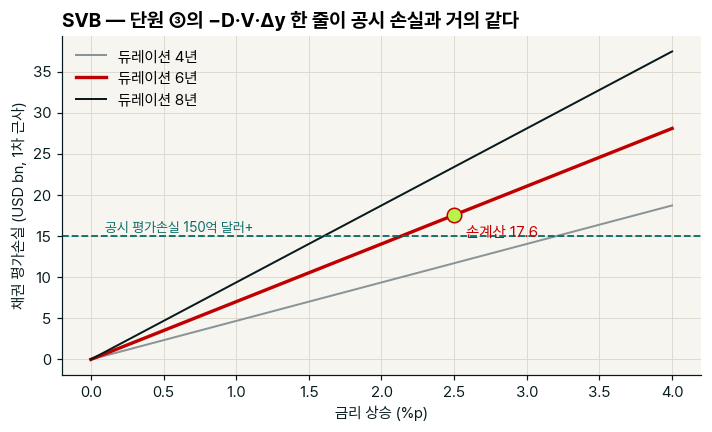

In [12]:
dys = np.linspace(0, 0.04, 41)
fig, ax = plt.subplots(figsize=(7.5, 4))
for D_, c in [(4, GRAY), (6, RED), (8, INK)]:
    ax.plot(dys * 100, D_ * V_svb * dys, color=c, lw=2.2 if D_ == 6 else 1.3, label=f"듀레이션 {D_}년")
ax.axhline(15, color=TEAL, ls="--", lw=1.2); ax.text(0.1, 15.6, "공시 평가손실 150억 달러+", color=TEAL, fontsize=9)
ax.scatter(2.5, -loss, s=90, color=LIME, edgecolor=RED, zorder=5)
ax.annotate(f"손계산 {-loss:.1f}", (2.5, -loss), textcoords="offset points", xytext=(8, -14), color=RED)
ax.set_xlabel("금리 상승 (%p)"); ax.set_ylabel("채권 평가손실 (USD bn, 1차 근사)")
ax.set_title("SVB — 단원 ③의 −D·V·Δy 한 줄이 공시 손실과 거의 같다")
ax.legend()
plt.show()

## 7. 정리
- 2022 영국 연기금: 짧은 자산을 **스왑으로 늘려** 헤지 → 금리가 빠르게 오르자 **증거금**에서 무너짐.
- 2023 SVB: 짧은 예금 앞에 긴 채권을 들고 **헤지하지 않음** → 금리 상승의 평가손실이 **인출**에서 터짐.
- 갭의 방향은 달라도 시험은 현금. 버퍼 150bp의 차이가 강제매도 여부를 가른다 — 영국 규제 250bp의 근거. 국민연금 안 C는 사흘 +200bp 증거금 401조 vs 유동자산 123조 → 07 노트북.

---
### 확인 결과 요약
이 노트북에서 강의본 숫자와 비교한 항목을 모아 봅니다. 모두 ✓이면 강의본 숫자를 그대로 재현한 것입니다.

In [13]:
# ── 확인 결과 요약 ──
n_ok = sum(ok for _, ok in CHECKS)
print(f"강의본 숫자 확인 {n_ok} / {len(CHECKS)} 통과" + (" — 빠른 모드라 일부 차이는 정상" if FAST else ""))
for label, ok in CHECKS:
    if not ok:
        print("  ✗", label)

강의본 숫자 확인 52 / 52 통과


---
## 바꿔 보기 (연습 문제)

1. `ldi_crisis(100, lev=3, haircut=0.10)` — 투매 할인을 3% → 10%로 키우면 강제 매도와 ΔFR은? (가격 충격을 넣은 아주 간단한 흉내)
2. 금리 경로를 +80bp × 3일 → −100bp로 바꾸면 버퍼 250bp도 고갈되는가? 고갈되지 않는 최소 버퍼(bp)를 찾아보라.
3. 실습 C에서 출발 FR을 90% → 110%로 바꾸면 헤지 0%일 때 ±100bp의 ΔFR은? 왜 적립이 좋은 기금도 금리 하락에 FR이 떨어지는가?

아래 빈 셀에서 직접 해 보세요. 위 셀의 함수를 그대로 불러 쓰면 됩니다.

In [14]:
# 여기에 직접 해 보기

In [15]:
# 여기에 직접 해 보기

In [16]:
# 여기에 직접 해 보기